In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("customer.csv")
df.head()

,CustomerID,Age,Income,SpendingScore,AnnualSpend
0,1,19,15000,39,12000
1,2,21,18000,81,20000
2,3,25,20000,6,5000
3,4,27,22000,77,25000
4,5,30,25000,40,15000


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     20 non-null     int64
 1   Age            20 non-null     int64
 2   Income         20 non-null     int64
 3   SpendingScore  20 non-null     int64
 4   AnnualSpend    20 non-null     int64
dtypes: int64(5)
memory usage: 932.0 bytes


,CustomerID,Age,Income,SpendingScore,AnnualSpend
count,20.00000,20.000000,20.00000,20.000000,20.000000
mean,10.50000,39.100000,33950.00000,54.600000,22050.000000
std,5.91608,13.070256,12995.84954,29.396384,13339.592829
min,1.00000,19.000000,15000.00000,6.000000,5000.000000
25%,5.75000,27.750000,22750.00000,32.500000,12000.000000
50%,10.50000,39.000000,33500.00000,57.500000,17500.000000
75%,15.25000,50.500000,42750.00000,80.250000,30500.000000
max,20.00000,60.000000,60000.00000,95.000000,50000.000000


In [12]:
df = df.dropna()
print(df)

    CustomerID  Age  Income  SpendingScore  AnnualSpend
0            1   19   15000             39        12000
1            2   21   18000             81        20000
2            3   25   20000              6         5000
3            4   27   22000             77        25000
4            5   30   25000             40        15000
5            6   35   30000             76        30000
6            7   40   35000             15         8000
7            8   45   40000             80        32000
8            9   50   42000             25        10000
9           10   52   45000             90        40000
10          11   55   50000             20        12000
11          12   60   60000             85        45000
12          13   23   17000             60        18000
13          14   28   23000             55        16000
14          15   33   28000             45        14000
15          16   38   32000             70        28000
16          17   42   37000             10      

In [13]:
X = df.select_dtypes(include=np.number)
X.head()

,CustomerID,Age,Income,SpendingScore,AnnualSpend
0,1,19,15000,39,12000
1,2,21,18000,81,20000
2,3,25,20000,6,5000
3,4,27,22000,77,25000
4,5,30,25000,40,15000


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-1.64750894 -1.57779355 -1.49603839 -0.54446365 -0.7729683 ]
 [-1.47408695 -1.42079917 -1.25919854  0.92140002 -0.15767015]
 [-1.30066495 -1.1068104  -1.1013053  -1.69621368 -1.31135419]
 [-1.12724296 -0.94981602 -0.94341207  0.78179396  0.22689119]
 [-0.95382097 -0.71432444 -0.70657222 -0.50956213 -0.5422315 ]
 [-0.78039897 -0.32183849 -0.31183914  0.74689244  0.61145254]
 [-0.60697698  0.07064747  0.08289395 -1.38210003 -1.08061738]
 [-0.43355498  0.46313343  0.47762703  0.88649851  0.76527708]
 [-0.26013299  0.85561939  0.63552026 -1.03308487 -0.92679284]
 [-0.086711    1.01261377  0.87236011  1.23551367  1.38057523]
 [ 0.086711    1.24810535  1.2670932  -1.20759245 -0.7729683 ]
 [ 0.26013299  1.64059131  2.05655936  1.06100609  1.76513657]
 [ 0.43355498 -1.26380479 -1.33814515  0.18846819 -0.31149469]
 [ 0.60697698 -0.87131883 -0.86446545  0.01396061 -0.46531923]
 [ 0.78039897 -0.47883287 -0.46973237 -0.33505455 -0.61914377]
 [ 0.95382097 -0.08634691 -0.1539459   0.53748335  0.45

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,-2.750929,0.753588
1,-1.711943,1.872886
2,-2.805758,-0.679985
3,-1.041017,1.598469
4,-1.518189,0.140120


In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

C:\Users\admin\Downloads\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [21]:
pca_df["Cluster"] = labels
pca_df.head()

,PC1,PC2,Cluster
0,-2.750929,0.753588,2
1,-1.711943,1.872886,2
2,-2.805758,-0.679985,2
3,-1.041017,1.598469,2
4,-1.518189,0.140120,2


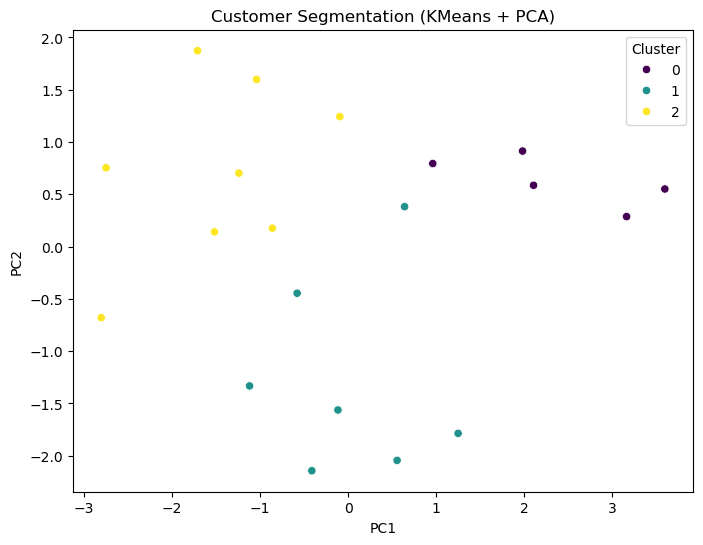

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=pca_df,    palette="viridis")

plt.title("Customer Segmentation (KMeans + PCA)")
plt.show()

In [35]:
df["Cluster"] = labels

cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
cluster_summary

,CustomerID,Age,Income,SpendingScore,AnnualSpend
Cluster,,,,,
0,13.600000,52.600000,47600.000000,87.600000,41000.000000
1,13.428571,44.428571,38714.285714,31.428571,13571.428571
2,6.000000,26.000000,21250.000000,54.250000,17625.000000


In [31]:
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.33341031313295794


# Customer Segmentation using Clustering and Dimensionality Reduction

## Objective

The objective of this project is to segment customers into different groups based on their characteristics using clustering techniques. Principal Component Analysis (PCA) was used to reduce dimensionality and visualize customer segments.

---

## Dataset Description

The dataset contains customer information including:

* CustomerID
* Age
* Income
* SpendingScore
* AnnualSpend

These features were used to identify groups of customers with similar behaviors and characteristics.

---

## Libraries Used

* Pandas
* NumPy
* Matplotlib
* Seaborn
* StandardScaler
* PCA
* KMeans
* Silhouette Score

---

## Data Preprocessing

The following preprocessing steps were performed:

1. Loaded the dataset using Pandas.
2. Examined dataset structure using `info()` and `describe()`.
3. Removed missing values using `dropna()`.
4. Selected numerical features for clustering.
5. Applied StandardScaler to normalize the data.

---

## Dimensionality Reduction

Principal Component Analysis (PCA) was applied to reduce the dataset into two principal components:

* PC1 (Principal Component 1)
* PC2 (Principal Component 2)

This made it possible to visualize customer segments in a two-dimensional space while preserving most of the information in the dataset.

---

## Clustering Method

K-Means Clustering was used to segment customers.

Model configuration:

* Number of Clusters: 3
* Random State: 42

The algorithm grouped customers into three clusters based on similarities in their numerical features.

---

## Cluster Visualization

The PCA-transformed data was visualized using a scatter plot. Different colors represented different customer segments identified by the K-Means algorithm.

The visualization helped in understanding the separation and distribution of customer groups.

---

## Cluster Analysis

A cluster summary table was generated using the mean values of each feature for every cluster.

### Cluster 0

Represents customers with similar characteristics grouped together by the model.

### Cluster 1

Represents another customer segment with distinct behavioral patterns.

### Cluster 2

Represents a separate customer group identified based on feature similarities.

The cluster summary table can be used to compare average age, income, spending score, and annual spending across clusters.

---

## Model Evaluation

The Silhouette Score was calculated to evaluate clustering performance.

The Silhouette Score measures how well-separated the clusters are and how similar data points are within the same cluster.

A higher score indicates better clustering quality.

---

## Results

* Successfully applied K-Means clustering.
* Reduced dimensionality using PCA.
* Visualized customer segments using scatter plots.
* Generated cluster summaries for interpretation.
* Evaluated clustering quality using Silhouette Score.

---

## Conclusion

Customer segmentation was successfully performed using K-Means clustering and PCA. The model identified distinct customer groups based on customer characteristics. These segments can help organizations understand customer behavior, improve marketing strategies, and support data-driven decision-making.
